>### Assignment: Cloning Quasars
Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey (SDSS).
The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST (and EUCLID), while we already are collecting data w DESI and DES). The latest public data release as of 2025 is SDSS Data Release 19 (DR19) with over a billion photometric objects and over 3 million spectroscopically confirmed galaxies or quasars.  

Download the SDSS quasar data. There is an older version (see Davide's implementation). Here I will use the latest one, DR16. However, this is a very large file. Do not try to download unless you are on your own machine. Instead, you can find the extracted redshifts in a Data folder on GitHub (see below how to access). There many other interesting data points in the fits file that we could play with.  

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [14]:
z_clean = np.load("quasar_redshifts.npz")["z"]

Now comes the assignment:

- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distributions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures).

(Hint: `scipy.stats` is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theoretical distribution to the measured SDSS data

(Hint: `astropy.cosmology` is another close friend). The best-fit cosmological model from the Planck data is:

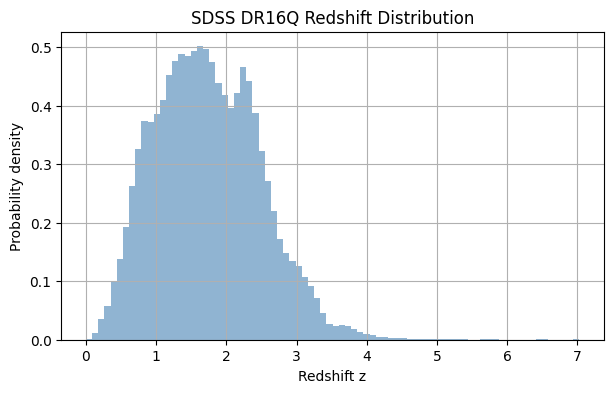

In [15]:
# Let us load the data we just saved and plot the Quasar distribution as a function of redshift

plt.figure(figsize=(7,4))
plt.hist(z_clean, bins=80, alpha=0.6, density=True, color="steelblue")
plt.xlabel("Redshift z")
plt.ylabel("Probability density")
plt.title("SDSS DR16Q Redshift Distribution")
plt.grid(True)
plt.show()


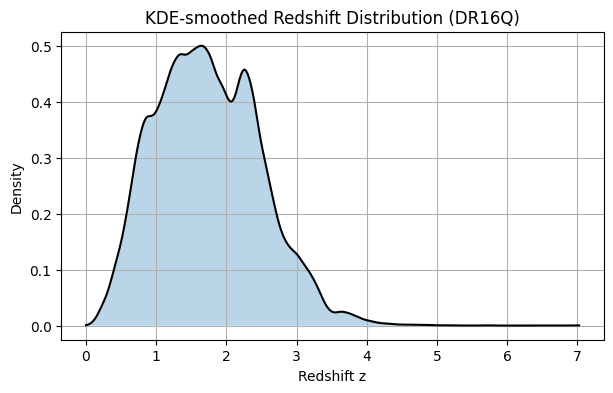

In [16]:
# Now plot the KDE-smoothed version of the redshift distribution. We can use this to compute the CDF as well and the inverse CDF if desired.
# KDE stands for Kernel Density Estimation, which is a non-parametric way to estimate the probability density function of a random variable. It works by placing a kernel (a smooth, symmetric function) on each data point and summing these kernels to create a smooth estimate of the density. In this case, we use a Gaussian kernel, which is commonly used for KDE. See more on this later. 

kde = gaussian_kde(z_clean)
zs = np.linspace(0, np.max(z_clean), 300)

plt.figure(figsize=(7,4))
plt.plot(zs, kde(zs), color="black")
plt.fill_between(zs, kde(zs), alpha=0.3)
plt.xlabel("Redshift z")
plt.ylabel("Density")
plt.title("KDE-smoothed Redshift Distribution (DR16Q)")
plt.grid(True)
plt.show()

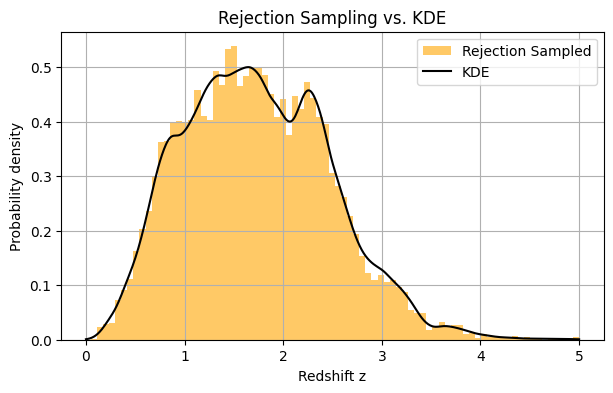

In [17]:
# Now using rejection sampling

N_samples = 10000
z_min = 0 # minimum redshift
z_max = 5 # maximum redshift
kde = gaussian_kde(z_clean) # KDE of the redshift distribution
zs = np.linspace(z_min, z_max, 500) # z values for evaluating the KDE
kde_vals = kde(zs) # evaluate the KDE
kde_max = np.max(kde_vals) # maximum KDE value for rejection sampling

random_z = [] # list to hold accepted random redshifts, regular python list
batch_size = 100 # number of random points to generate per batch

while len(random_z) < N_samples: # continue until we have enough samples
    z_rand = np.random.uniform(z_min, z_max, batch_size) # random z values
    y_rand = np.random.uniform(0, kde_max, batch_size) # random y values for rejection sampling
    kde_rand = np.interp(z_rand, zs, kde_vals) # evaluate KDE at random z values
    accepted = z_rand[y_rand < kde_rand] # accept points below the KDE curve, z_rand[true] gives the accepted z values
    # Boolean indexing: y_rand < kde_rand returns a boolean array where True indicates accepted points, and z_rand[True] gives the corresponding z values that were accepted.
    random_z.extend(accepted.tolist()) # add accepted points to the list
    # accepted is a numpy array of accepted z values, we convert it to a list and extend the random_z list with these values, extend() needs a list input

random_z = np.array(random_z[:N_samples]) # convert to numpy array and trim to desired size

plt.figure(figsize=(7,4))
plt.hist(random_z, bins=80, alpha=0.6, density=True, color="orange", label="Rejection Sampled")
plt.plot(zs, kde_vals, color="black", label="KDE")
plt.xlabel("Redshift z")
plt.ylabel("Probability density")
plt.title("Rejection Sampling vs. KDE")
plt.legend()
plt.grid(True)
plt.show()

That looks pretty nice! So rejection sampling works.

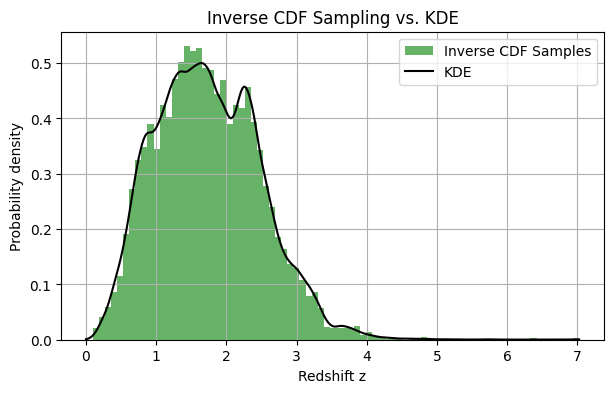

In [18]:
# Now using inverse transform sampling

# Let us first interpolate the KDE for faster evaluation
from scipy.interpolate import interp1d # for interpolation
kde_interp = interp1d(zs, kde_vals, bounds_error=False, fill_value=0)
# Now we can use this interpolated function to compute the CDF and inverse CDF as needed.

from scipy.integrate import cumulative_trapezoid # for cumulative integration
# Compute the CDF from the KDE using cumulative trapezoidal integration
kde = gaussian_kde(z_clean) # KDE of the redshift distribution
zs = np.linspace(0, np.max(z_clean), 300) # z values for evaluating the KDE
kde_vals = kde(zs) # evaluate the KDE
cdf_vals = cumulative_trapezoid(kde_vals, zs, initial=0) # cumulative integral to get CDF
cdf_vals /= cdf_vals[-1] # normalize CDF to 1

# Create an interpolating function for the inverse CDF
inverse_cdf = interp1d(cdf_vals, zs, bounds_error=False, fill_value=(zs[0], zs[-1]))
# Now we can generate random samples using the inverse CDF method
N_samples = 10000
u_random = np.random.uniform(0, 1, N_samples) # uniform random numbers
z_samples = inverse_cdf(u_random) # map to redshift samples
plt.figure(figsize=(7,4))
plt.hist(z_samples, bins=80, alpha=0.6, density=True, color="green", label="Inverse CDF Samples")
plt.plot(zs, kde_vals, color="black", label="KDE")
plt.xlabel("Redshift z")
plt.ylabel("Probability density")
plt.title("Inverse CDF Sampling vs. KDE")
plt.legend()
plt.grid(True)
plt.show()

So both methods seem to work and reproduce the quasar redshift distribution. In this way you can keep on generating 'mock' catalogs.

In [ ]:
import astropy
from astropy.cosmology import Planck18
astropy.cosmology.Planck18

In [ ]:
# You can get each parameter like this:
H0 = Planck18.H0.value  # Hubble constant at z=0 in km/s/Mpc, parameter that describes the expansion rate of the universe at the current epoch
Om0 = Planck18.Om0  # Omega matter at z=0, parameter that describes the matter density of the universe at the current epoch

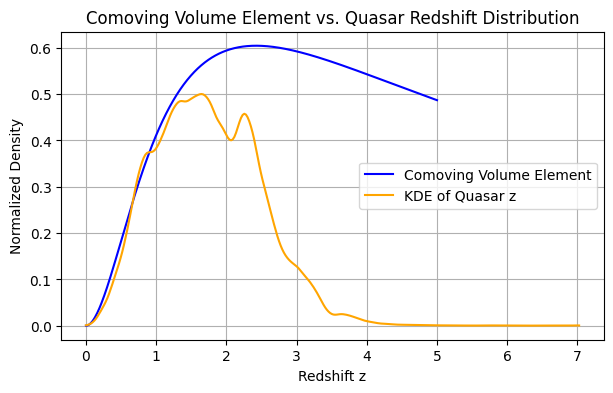

In [19]:
# Now we want to compare the distribution to the comoving volume element as a function of redshift.
# That is, we want to compute dV/dz and compare it to the KDE of the quasar redshifts. The idea is that we expect the quasar distribution to roughly follow the comoving volume element.
# The comoving volume element dV/dz describes how the volume of the universe changes with redshift. If quasars were uniformly distributed in space and there were no selection effects, we would expect their redshift distribution to follow this comoving volume element. However, in reality, we might see deviations from this due to various factors such as selection effects (e.g., we might be more likely to detect brighter quasars at certain redshifts), luminosity evolution (quasars might have been more or less luminous in the past), and other astrophysical processes that affect quasar formation and visibility over cosmic time.

# Define redshift range
z = np.linspace(0, 5, 500)
# Compute comoving volume element dV/dz using astropy
dV_dz = Planck18.differential_comoving_volume(z).value  # in Mpc^3 / sr / dz
# Normalize the integral for comparison
dV_dz /= np.trapezoid(dV_dz, z)  # normalize to unit integral
# Plot the results and compare to KDE of quasar redshifts
plt.figure(figsize=(7,4))
plt.plot(z, 2.4*dV_dz, label='Comoving Volume Element', color='blue') #2.4 is norm by eye, same as Davide found.
plt.plot(zs, kde_vals/np.trapezoid(kde_vals, zs), label='KDE of Quasar z', color='orange')
plt.xlabel('Redshift z')
plt.ylabel('Normalized Density')
plt.title('Comoving Volume Element vs. Quasar Redshift Distribution')
plt.legend()
plt.grid(True)
plt.show()

They are only uniformly distributed at low redshift. If all quasars are the same, why do we only see them differently?